# 5장: 전이 학습 (Transfer Learning)
## 딥러닝 파이토치 교과서 pp.199~241
### 내용: 특성 추출 기법, 미세 조정 기법, 설명 가능한 CNN, 그래프 합성곱 네트워크

## 5.3.1 특성 추출 기법 (Feature Extraction)
### 필요 라이브러리 설치
```bash
pip install opencv-python
```

In [1]:
import os
import time
import copy
import glob
import cv2
import shutil
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
print('라이브러리 로드 완료')

라이브러리 로드 완료


### 데이터 전처리 및 데이터로더 설정
> 데이터셋 경로: `../chap05/data/catanddog/train`  
> 데이터는 https://www.kaggle.com/c/dogs-vs-cats/data 에서 다운로드 가능

In [2]:
data_path = '../chap05/data/catanddog/train'

transform = transforms.Compose([
    transforms.Resize([256, 256]),          # ① 이미지 크기를 256x256으로 조정
    transforms.RandomResizedCrop(224),      # ② 랜덤한 크기 및 비율로 자름 (데이터 확장)
    transforms.RandomHorizontalFlip(),      # ③ 이미지를 랜덤하게 수평으로 뒤집음
    transforms.ToTensor()                   # ④ 이미지 데이터를 텐서로 변환
])

if os.path.exists(data_path):
    train_dataset = torchvision.datasets.ImageFolder(
        data_path,
        transform=transform
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=32,
        num_workers=0,     # macOS에서는 0 권장
        shuffle=True
    )
    print(len(train_dataset))
else:
    print(f'[안내] 데이터 경로({data_path})가 없습니다. 데이터를 먼저 다운로드하세요.')

[안내] 데이터 경로(../chap05/data/catanddog/train)가 없습니다. 데이터를 먼저 다운로드하세요.


### transforms 파라미터 설명
- **Resize**: 합성곱층 통과를 위해 이미지 크기를 전처리
- **RandomResizedCrop**: 데이터 확장 용도 - 랜덤 비율로 자른 후 크기 조정
- **RandomHorizontalFlip**: 이미지를 랜덤하게 수평으로 뒤집어 데이터 다양성 증가
- **ToTensor**: 이미지를 [0,1] 범위의 텐서로 변환

### DataLoader 파라미터 설명
- `batch_size`: 한 번에 불러올 데이터 개수
- `num_workers`: 데이터를 불러올 때 사용하는 하위 프로세스 수 (너무 많으면 오류/메모리 부족)
- `shuffle`: True이면 데이터를 무작위로 섞어서 불러옴

### RandomResizedCrop 데이터 확장 예제
```bash
pip install mxnet
```

In [3]:
# mxnet 설치 후 실행 (커널 재시작 필요)
try:
    import mxnet as mx
    from mxnet.gluon.data.vision import transforms as mx_transforms

    example_image = mx.image.imread("../chap05/data/cat.jpg")
    plt.imshow(example_image.asnumpy())
    plt.title('원본 이미지')
    plt.show()

    def show_images(imgs, num_rows, num_cols, scale=2):
        aspect_ratio = imgs[0].shape[0] / imgs[0].shape[1]
        figsize = (num_cols * scale, num_rows * scale * aspect_ratio)
        _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
        for i in range(num_rows):
            for j in range(num_cols):
                axes[i][j].imshow(imgs[i * num_cols + j].asnumpy())
                axes[i][j].axes.get_xaxis().set_visible(False)  # x축 숨김
                axes[i][j].axes.get_yaxis().set_visible(False)  # y축 숨김
        plt.subplots_adjust(hspace=0.1, wspace=0)
        return axes

    def apply(img, aug, num_rows=2, num_cols=4, scale=3):
        # 다양한 샘플을 얻기 위해 여러 번 데이터 확장 적용
        Y = [aug(img) for _ in range(num_rows * num_cols)]
        show_images(Y, num_rows, num_cols, scale)

    # size: 200x200으로 출력
    # scale: 면적 비율 0.1~1(10~100%) 범위에서 무작위로 자름
    # ratio: 너비와 높이 비율을 0.5~2 범위에서 무작위 조절
    shape_aug = mx_transforms.RandomResizedCrop(size=(200, 200), scale=(0.1, 1), ratio=(0.5, 2))
    apply(example_image, shape_aug)
    plt.show()
except ImportError:
    print('[안내] mxnet이 설치되지 않았습니다. pip install mxnet 후 실행하세요.')

[안내] mxnet이 설치되지 않았습니다. pip install mxnet 후 실행하세요.


### 학습 데이터 시각화 (24개 이미지)

In [4]:
if 'train_loader' in dir():
    # iter() + next()로 반복자에서 첫 배치 추출
    samples, labels = next(iter(train_loader))
    classes = {0: 'cat', 1: 'dog'}

    fig = plt.figure(figsize=(16, 24))
    for i in range(24):
        a = fig.add_subplot(4, 6, i+1)
        a.set_title(classes[labels[i].item()])
        a.axis('off')
        # transpose(1,2,0): (C,H,W) -> (H,W,C) 형태로 변환하여 imshow에 전달
        a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0)))
    plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
    plt.show()
else:
    print('[안내] train_loader가 없습니다. 데이터셋을 먼저 준비하세요.')

[안내] train_loader가 없습니다. 데이터셋을 먼저 준비하세요.


### numpy.transpose 예시

In [5]:
exam = np.arange(24).reshape(2, 3, 4)
print('원본 shape:', exam.shape)
print(exam)
print()
transposed = np.transpose(exam, (2, 1, 0))  # (2,3,4) -> (4,3,2)
print('transpose 후 shape:', transposed.shape)
print(transposed)

원본 shape: (2, 3, 4)
[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]

transpose 후 shape: (4, 3, 2)
[[[ 0 12]
  [ 4 16]
  [ 8 20]]

 [[ 1 13]
  [ 5 17]
  [ 9 21]]

 [[ 2 14]
  [ 6 18]
  [10 22]]

 [[ 3 15]
  [ 7 19]
  [11 23]]]


### 사전 훈련된 ResNet18 불러오기

In [6]:
# pretrained=True: ImageNet으로 사전 학습된 가중치 사용
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print('ResNet18 로드 완료')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/jade/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  1%|          | 256k/44.7M [00:00<00:19, 2.34MB/s]

  2%|▏         | 768k/44.7M [00:00<00:12, 3.76MB/s]

  3%|▎         | 1.25M/44.7M [00:00<00:10, 4.36MB/s]

...

 91%|█████████ | 40.5M/44.7M [00:07<00:00, 7.68MB/s]

 93%|█████████▎| 41.5M/44.7M [00:07<00:00, 4.99MB/s]

 98%|█████████▊| 43.6M/44.7M [00:07<00:00, 7.75MB/s]

100%|██████████| 44.7M/44.7M [00:07<00:00, 6.06MB/s]

ResNet18 로드 완료


### 합성곱층 파라미터 고정 (특성 추출)

In [7]:
def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            # requires_grad=False: 역전파 중 파라미터 변화 계산 불필요 (가중치 고정)
            param.requires_grad = False

set_parameter_requires_grad(resnet18)
print('합성곱층 파라미터 고정 완료')

합성곱층 파라미터 고정 완료


### ResNet18 마지막에 완전연결층 추가

In [8]:
resnet18.fc = nn.Linear(512, 2)  # 2: 클래스 수 (cat, dog)

# 학습 가능한 파라미터 확인 (완전연결층만 학습)
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[ 0.0286,  0.0059, -0.0098,  ..., -0.0194,  0.0030,  0.0374],
        [-0.0419, -0.0003,  0.0112,  ..., -0.0065,  0.0247,  0.0349]])
fc.bias tensor([ 0.0367, -0.0440])


### 모델 객체 생성 및 손실 함수 정의

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():      # 전체 가중치 고정
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters():  # 완전연결층만 학습
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 모델 학습 함수 정의

In [10]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()  # 컴퓨터의 현재 시각
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):  # 에포크(13)만큼 반복
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:  # 데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            labels = labels.to(device)
            model.to(device)

            optimizer.zero_grad()           # 기울기를 0으로 설정
            outputs = model(inputs)         # 순전파 학습
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            loss.backward()                 # 역전파 학습
            optimizer.step()

            # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
            running_loss += loss.item() * inputs.size(0)
            # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders.dataset)           # 평균 오차 계산
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)  # 평균 정확도 계산

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)

        os.makedirs('../chap05/data/catanddog/', exist_ok=True)
        torch.save(model.state_dict(), os.path.join('../chap05/data/catanddog/',
                                                     '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since  # 실행 시간(학습 시간) 계산
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history, loss_history  # 모델의 정확도와 오차를 반환

print('train_model 함수 정의 완료')

train_model 함수 정의 완료


### 업데이트할 파라미터 설정

In [11]:
params_to_update = []
for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)  # 파라미터 학습 결과를 저장
        print("\t", name)

optimizer = optim.Adam(params_to_update)  # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


### 모델 학습 실행

In [12]:
if 'train_loader' in dir():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.CrossEntropyLoss()  # 손실 함수 지정
    train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)
else:
    print('[안내] 데이터셋이 없어 학습을 건너뜁니다.')
    # 시각화 데모용 가상 데이터
    train_acc_hist = [0.72, 0.79, 0.90, 0.88, 0.80, 0.83, 0.94, 0.91, 0.92, 0.91, 0.85, 0.94, 0.92]
    train_loss_hist = [0.56, 0.44, 0.31, 0.31, 0.41, 0.36, 0.21, 0.21, 0.20, 0.23, 0.30, 0.19, 0.20]

[안내] 데이터셋이 없어 학습을 건너뜁니다.


### 테스트 데이터 준비

In [13]:
test_path = '../chap05/data/catanddog/test'

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

if os.path.exists(test_path):
    test_dataset = torchvision.datasets.ImageFolder(
        root=test_path,
        transform=test_transform
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=32,
        num_workers=0,
        shuffle=True
    )
    print(len(test_dataset))
else:
    print('[안내] 테스트 데이터 경로가 없습니다.')

[안내] 테스트 데이터 경로가 없습니다.


### 모델 평가 함수 정의

In [14]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    # glob: 특정 경로에서 원하는 확장자 파일만 추출
    saved_models = glob.glob('../chap05/data/catanddog/' + '*.pth')
    saved_models.sort()  # 정렬
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)

        running_corrects = 0

        for inputs, labels in dataloaders:  # 테스트 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():  # autograd를 사용하지 않음
                outputs = model(inputs)  # 데이터를 모델에 적용

            # torch.max: 텐서 배열의 최댓값 인덱스 반환
            _, preds = torch.max(outputs.data, 1)

            preds[preds >= 0.5] = 1   # 0.5보다 크면 올바르게 예측
            preds[preds < 0.5] = 0    # 0.5보다 작으면 틀리게 예측
            # preds.eq(labels): 예측과 정답 일치 여부 검사 / .sum(): 일치 개수 합산
            running_corrects += preds.eq(labels.cpu()).int().sum()

        epoch_acc = running_corrects.double() / len(dataloaders.dataset)
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())

    print()
    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history  # 계산된 정확도 반환

print('eval_model 함수 정의 완료')

eval_model 함수 정의 완료


In [15]:
if 'test_loader' in dir():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    val_acc_hist = eval_model(resnet18, test_loader, device)
else:
    print('[안내] 테스트 데이터가 없어 건너뜁니다.')
    val_acc_hist = [0.73, 0.89, 0.92, 0.89, 0.94, 0.93, 0.93, 0.91, 0.94, 0.95, 0.93, 0.93, 0.93]

[안내] 테스트 데이터가 없어 건너뜁니다.


### 정확도 및 오차 시각화

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

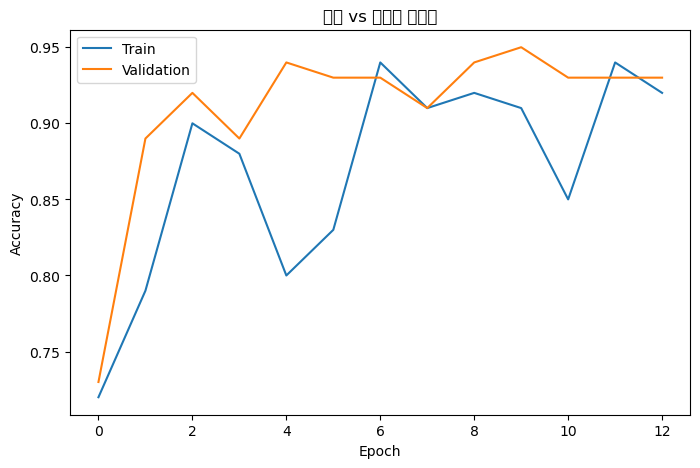

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_hist, label='Train')
plt.plot(val_acc_hist, label='Validation')
plt.title('훈련 vs 테스트 정확도')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

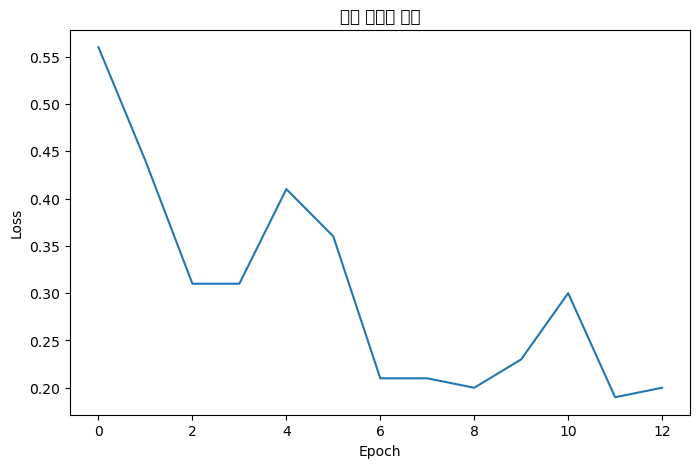

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_hist)
plt.title('훈련 데이터 오차')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### 예측 결과 이미지 시각화

In [18]:
def im_convert(tensor):
    # tensor.clone().detach(): 기존 텐서를 복사하지만 기울기에 영향을 주지 않음
    image = tensor.clone().detach().numpy()
    image = image.transpose(1, 2, 0)
    image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))
    # clip(0,1): 이미지 데이터를 0~1 사이 값으로 제한
    image = image.clip(0, 1)
    return image

In [19]:
# clip 예시
import numpy as np
exam = np.array([-1.8, -1.2, -0.7, 0.0, 0.8, 1.4, 1.9])
print('원본:', exam)
print('clip(-0.5, 0.5):', np.clip(exam, -0.5, 0.5))

원본: [-1.8 -1.2 -0.7  0.   0.8  1.4  1.9]
clip(-0.5, 0.5): [-0.5 -0.5 -0.5  0.   0.5  0.5  0.5]


In [20]:
if 'test_loader' in dir():
    classes = {0: 'cat', 1: 'dog'}
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    output = model(images)
    _, preds = torch.max(output, 1)

    fig = plt.figure(figsize=(25, 4))
    for idx in np.arange(20):
        # add_subplot(행수, 열수, 인덱스, ...): 한 화면에 여러 이미지 배치
        ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
        plt.imshow(im_convert(images[idx]))
        ax.set_title(
            "{}({})".format(
                str(classes[preds[idx].item()]),
                str(classes[labels[idx].item()])
            ),
            # 예측이 맞으면 초록색, 틀리면 빨간색
            color=("green" if preds[idx] == labels[idx] else "red")
        )
    plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
    plt.show()
else:
    print('[안내] 테스트 데이터가 없어 건너뜁니다.')

[안내] 테스트 데이터가 없어 건너뜁니다.


---
## 5.4 설명 가능한 CNN (Explainable CNN / XAI)
```bash
pip install pillow
```

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('device:', device)

device: cpu


### XAI 모델 정의 (13개 합성곱층 + 2개 완전연결층)

In [22]:
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),  # inplace=True: 기존 데이터를 연산 결과로 대체
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 512, bias=False),
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        # log_softmax: 소프트맥스 결과에 log를 취함 (기울기 소멸 문제 완화)
        return F.log_softmax(x, dim=1)

xai_model = XAI()
xai_model.to(device)
xai_model.eval()
print(xai_model)

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

### LayerActivations: hook으로 특성 맵 추출

In [23]:
class LayerActivations:
    features = []

    def __init__(self, model, layer_num):
        # register_forward_hook: 순전파 중 각 계층의 입력/출력을 가져옴
        self.hook = model[layer_num].register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
        self.features = output.detach().numpy()

    def remove(self):  # hook 삭제
        self.hook.remove()

print('LayerActivations 클래스 정의 완료')

LayerActivations 클래스 정의 완료


### hook을 통한 중간 변수 기울기 확인 예시

In [24]:
x = torch.Tensor([0, 1, 2, 3]).requires_grad_()
y = torch.Tensor([4, 5, 6, 7]).requires_grad_()
w = torch.Tensor([1, 2, 3, 4]).requires_grad_()
z = x + y
o = w.matmul(z)
o.backward()
print('x.grad:', x.grad, '/ y.grad:', y.grad, '/ z.grad:', z.grad, '/ w.grad:', w.grad, '/ o.grad:', o.grad)
# z는 중간 변수이므로 기울기가 None → register_hook으로 확인 가능

x.grad: tensor([1., 2., 3., 4.]) / y.grad: tensor([1., 2., 3., 4.]) / z.grad: None / w.grad: tensor([ 4.,  6.,  8., 10.]) / o.grad: None


/var/folders/n4/c0yb6m6x0kx_h8gw6v4_ltf40000gn/T/ipykernel_45506/1295175339.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:499.)
  print('x.grad:', x.grad, '/ y.grad:', y.grad, '/ z.grad:', z.grad, '/ w.grad:', w.grad, '/ o.grad:', o.grad)


### unsqueeze 예시

In [25]:
x1 = torch.rand(3, 10, 64)
x2 = x1.unsqueeze(dim=0)  # [3, 10, 64] -> [1, 3, 10, 64]
print(x2.shape)
print('---')
x3 = x1.unsqueeze(dim=1)  # [3, 10, 64] -> [3, 1, 10, 64]
print(x3.shape)

torch.Size([1, 3, 10, 64])
---
torch.Size([3, 1, 10, 64])


### 이미지 불러오기 및 전처리

In [26]:
img_path = "../chap05/data/cat.jpg"

if os.path.exists(img_path):
    img = cv2.imread(img_path)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('입력 이미지')
    plt.show()

    # cv2.resize: 이미지 크기 변경 / INTER_LINEAR: 선형 보간법
    img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR)
    # ToTensor: 이미지를 텐서로 변환 / unsqueeze(0): 1차원 추가 [C,H,W] -> [1,C,H,W]
    img_tensor = ToTensor()(img).unsqueeze(0)
    print(img_tensor.shape)
else:
    print('[안내] cat.jpg가 없습니다. 임의 텐서로 대체합니다.')
    img_tensor = torch.rand(1, 3, 100, 100)

[안내] cat.jpg가 없습니다. 임의 텐서로 대체합니다.


### 0번째 합성곱층의 특성 맵 시각화

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

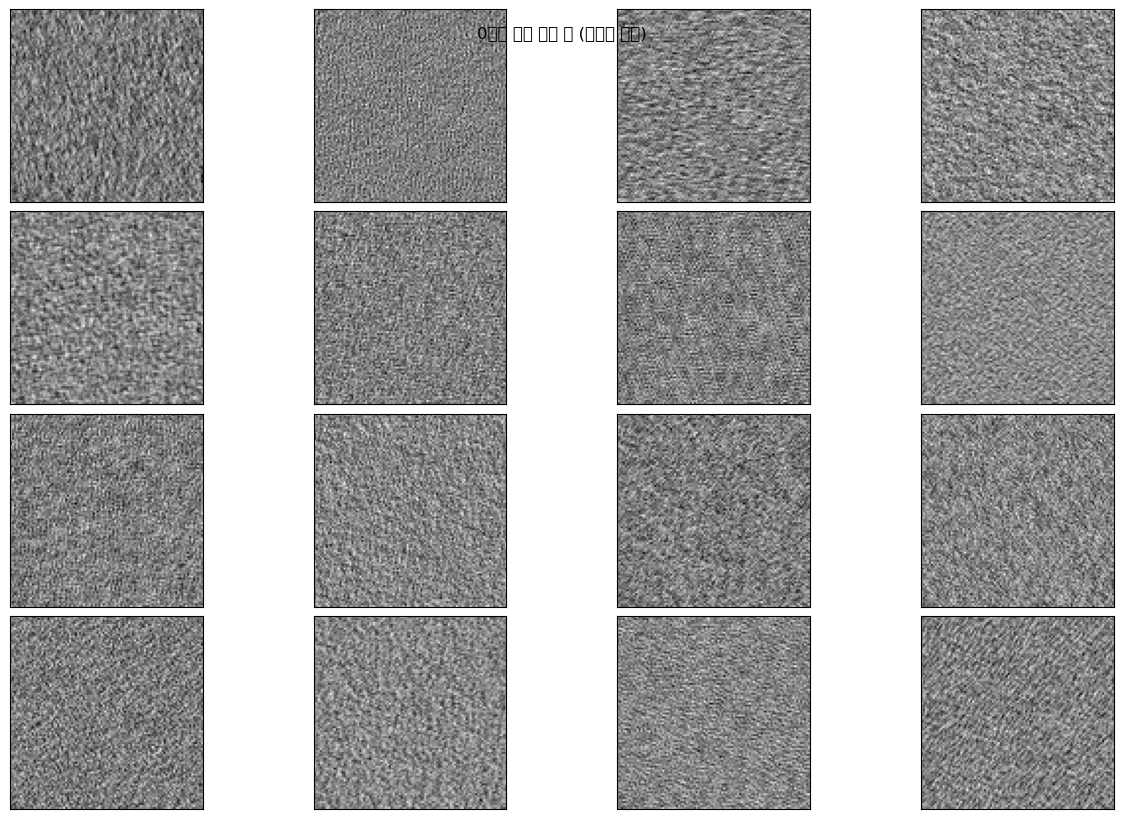

In [27]:
result = LayerActivations(xai_model.features, 0)  # 0번째 계층 특성 맵 확인
xai_model(img_tensor)
activations = result.features

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column], cmap='gray')
plt.suptitle('0번째 계층 특성 맵 (입력과 유사)')
plt.show()
result.remove()

### 20번째 합성곱층의 특성 맵 시각화

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

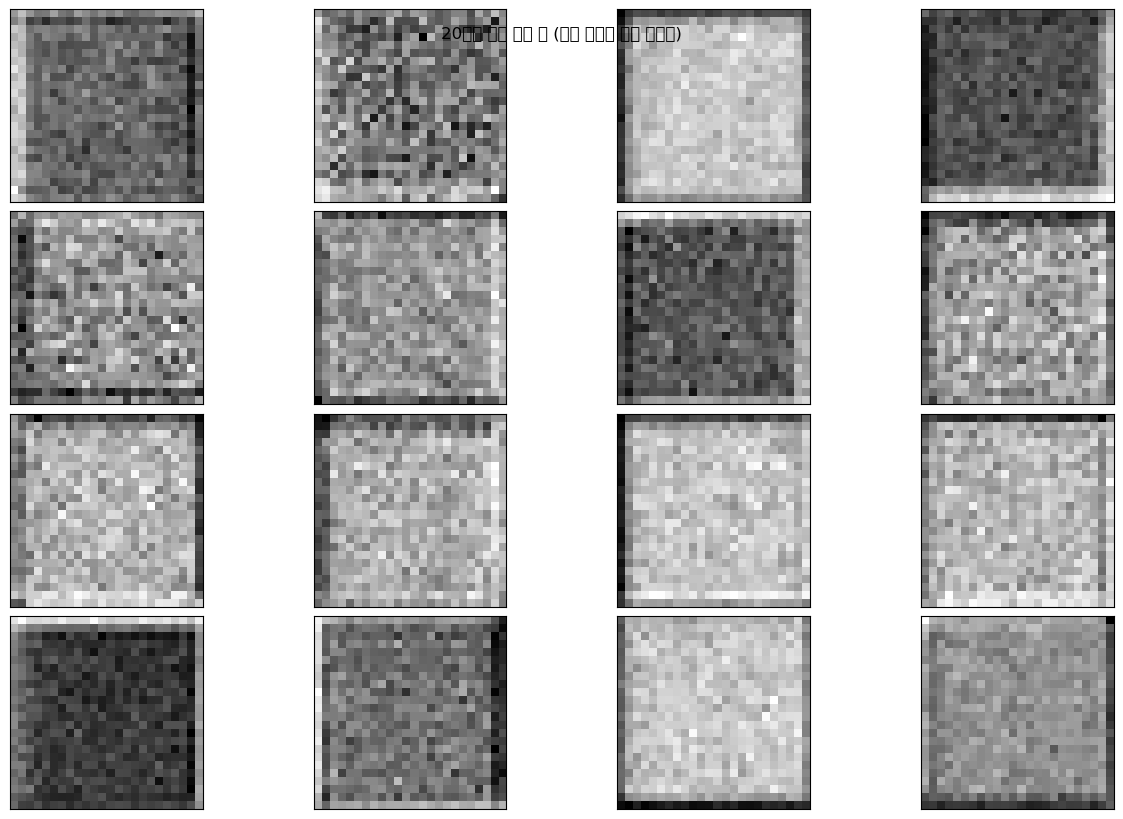

In [28]:
result = LayerActivations(xai_model.features, 20)  # 20번째 계층 특성 맵 확인
xai_model(img_tensor)
activations = result.features

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column], cmap='gray')
plt.suptitle('20번째 계층 특성 맵 (원본 이미지 형태 사라짐)')
plt.show()
result.remove()

### 40번째 합성곱층의 특성 맵 시각화

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51669 (\N{HANGUL SYLLABLE JING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


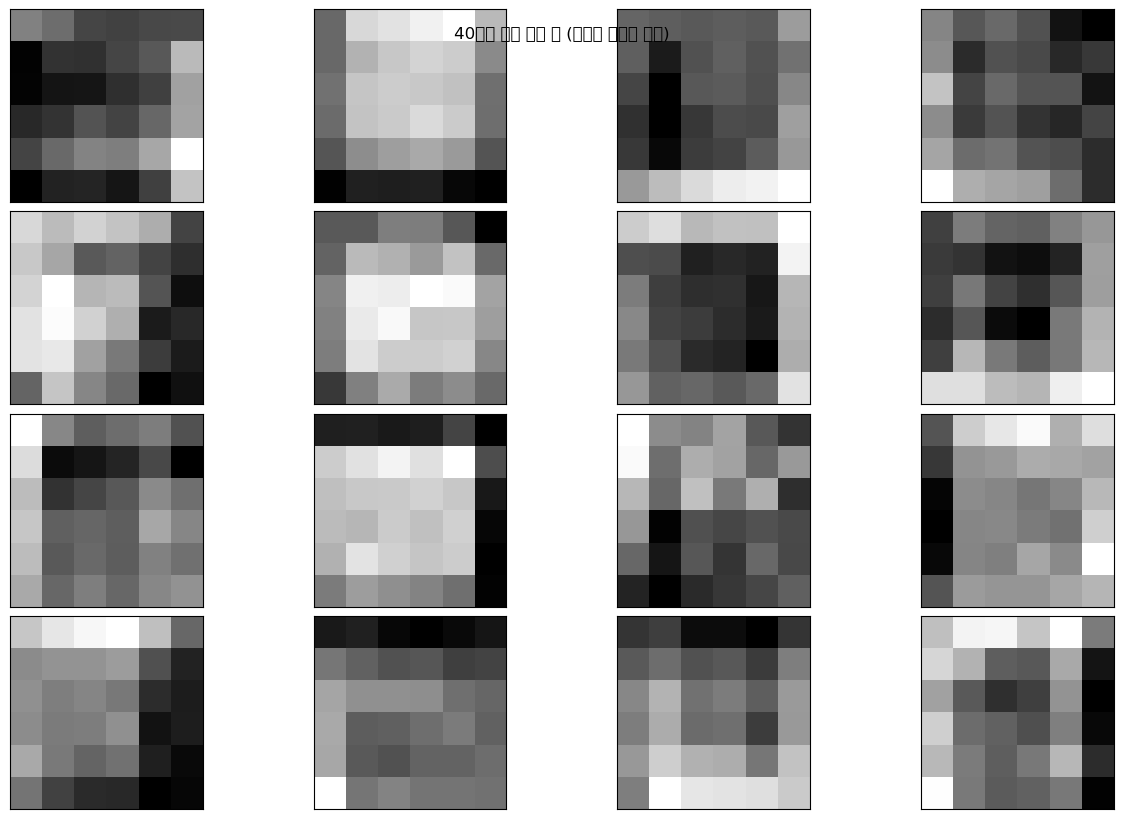

In [29]:
result = LayerActivations(xai_model.features, 40)  # 40번째 계층 특성 맵 확인
xai_model(img_tensor)
activations = result.features

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column], cmap='gray')
plt.suptitle('40번째 계층 특성 맵 (이미지 특징만 남음)')
plt.show()
result.remove()

---
## 5.5 그래프 합성곱 네트워크 (GCN)

그래프 합성곱 네트워크는 이미지 합성곱을 그래프 데이터로 확장한 알고리즘입니다.

### 그래프 데이터 표현 과정
1. **인접 행렬 (Adjacency Matrix)**: 노드 n을 n×n 행렬로 표현
2. **특성 행렬 (Feature Matrix)**: 각 입력 데이터에서 이용할 특성을 선택

### GCN 활용 분야
- SNS에서 관계 네트워크
- 학술 연구에서 인용 네트워크
- 3D Mesh

> GCN 구현은 추가 라이브러리(PyTorch Geometric 등)가 필요합니다.